# Phase 1 — Exploratory Data Analysis

Goals: class distribution & imbalance, a visual sample per class, and a full-dataset
manifest (image size, mode, file size, corruption check). These findings directly
inform Phase 2 (splits/transforms) and Phase 3 (loss weighting).

Data logic lives in `src/data/eda.py` -- this notebook only calls into it and plots.

In [1]:
# Colab only: mount Drive and cd into the synced project folder.
# Safe to run locally too -- the import fails there and this cell is skipped.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd "/content/drive/MyDrive/Colab Notebooks/Plant_Disease_Classification_Project"
except ImportError:
    pass

In [2]:
import sys, os

# Walk up from cwd to the project root (marked by configs/config.yaml) and put it on
# sys.path. Plain os.getcwd() isn't reliable here -- it depends on how the kernel was
# launched (VS Code's Jupyter extension defaults to the notebook's own folder, not the
# project root, which differs from how this ran on Linux before).
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "configs", "config.yaml")):
    _parent = os.path.dirname(_root)
    if _parent == _root:
        raise RuntimeError("Could not find project root (configs/config.yaml) above " + os.getcwd())
    _root = _parent
sys.path.append(_root)

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image

from src.utils.config import load_config
from src.data.fetch_data import fetch_dataset
from src.data import eda

cfg = load_config()
print("Environment:", cfg["env"])

fetch_dataset(cfg)  # no-op if already downloaded
DATA_PATH = cfg["data"]["path"]
DATA_PATH

Environment: local
Cloning https://github.com/spMohanty/PlantVillage-Dataset.git (sparse checkout: raw/color only) ...
Done. 38 class folders at C:\Diljith_AK\projects\plant_dataset\PlantVillage\color


'C:\\Diljith_AK\\projects\\plant_dataset\\PlantVillage\\color'

In [3]:
# Chart color tokens -- project convention (see dataviz reference palette).
# Single hue for magnitude encodings; the status color is reserved for a real
# data-quality flag (never reused as a plain series color).
COLOR_PRIMARY = "#2a78d6"
COLOR_CRITICAL = "#d03b3b"
COLOR_GRID = "#e1e0d9"
COLOR_AXIS = "#c3c2b7"
COLOR_TEXT = "#0b0b0b"
COLOR_TEXT_MUTED = "#52514e"

## 1. Class distribution

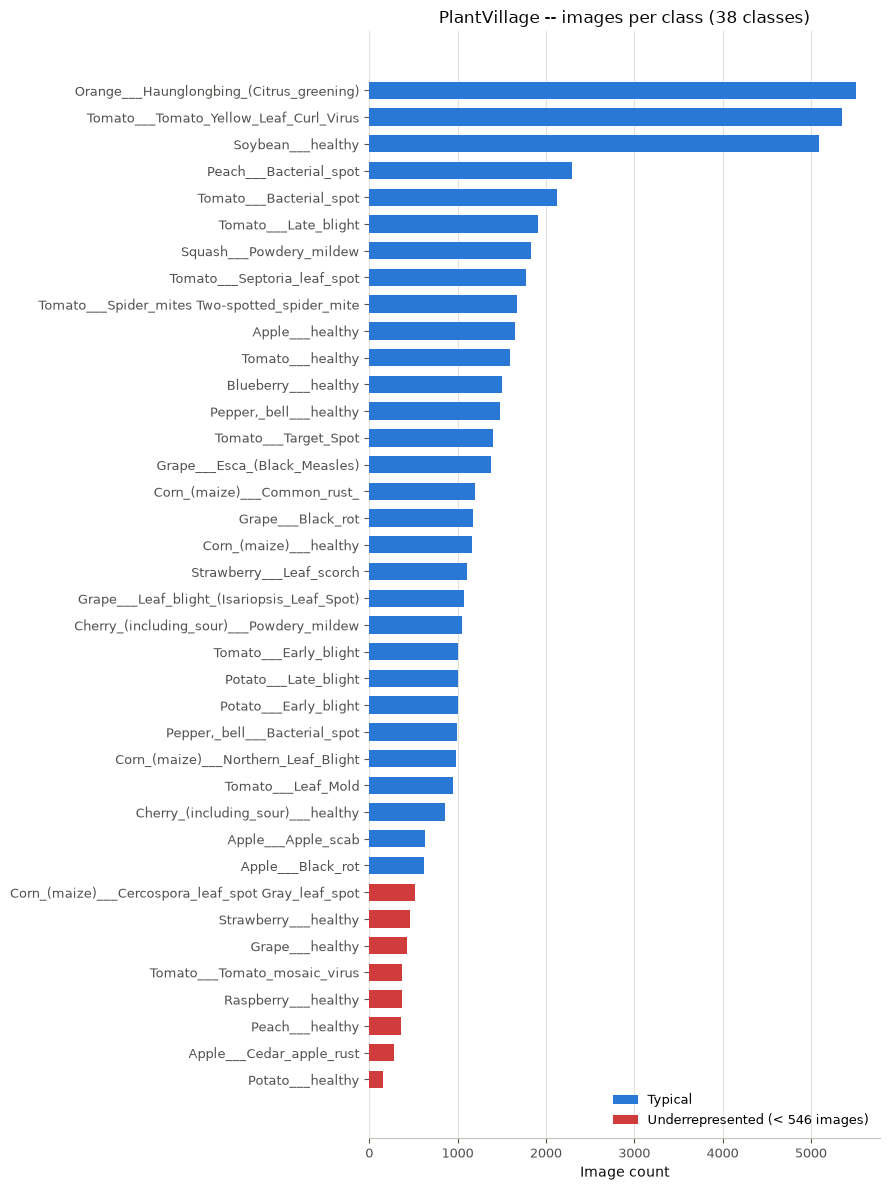

Classes: 38 | Total images: 54305
Smallest: Potato___healthy (152) | Largest: Orange___Haunglongbing_(Citrus_greening) (5507)
Imbalance ratio (max/min): 36.23x


In [4]:
counts = eda.class_counts(DATA_PATH).sort_values()

threshold = counts.median() * 0.5
colors = [COLOR_CRITICAL if c < threshold else COLOR_PRIMARY for c in counts]

fig, ax = plt.subplots(figsize=(9, 12))
ax.barh(counts.index, counts.values, color=colors, height=0.65, zorder=3)
ax.set_xlabel("Image count")
ax.set_title("PlantVillage -- images per class (38 classes)")
ax.grid(axis="x", color=COLOR_GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(COLOR_AXIS)
ax.tick_params(colors=COLOR_TEXT_MUTED, labelsize=9)
ax.xaxis.label.set_color(COLOR_TEXT)
ax.title.set_color(COLOR_TEXT)

legend_handles = [
    Patch(facecolor=COLOR_PRIMARY, label="Typical"),
    Patch(facecolor=COLOR_CRITICAL, label=f"Underrepresented (< {threshold:.0f} images)"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print(f"Classes: {len(counts)} | Total images: {counts.sum()}")
print(f"Smallest: {counts.idxmin()} ({counts.min()}) | Largest: {counts.idxmax()} ({counts.max()})")
print(f"Imbalance ratio (max/min): {counts.max() / counts.min():.2f}x")

## 2. Sample images -- one per class

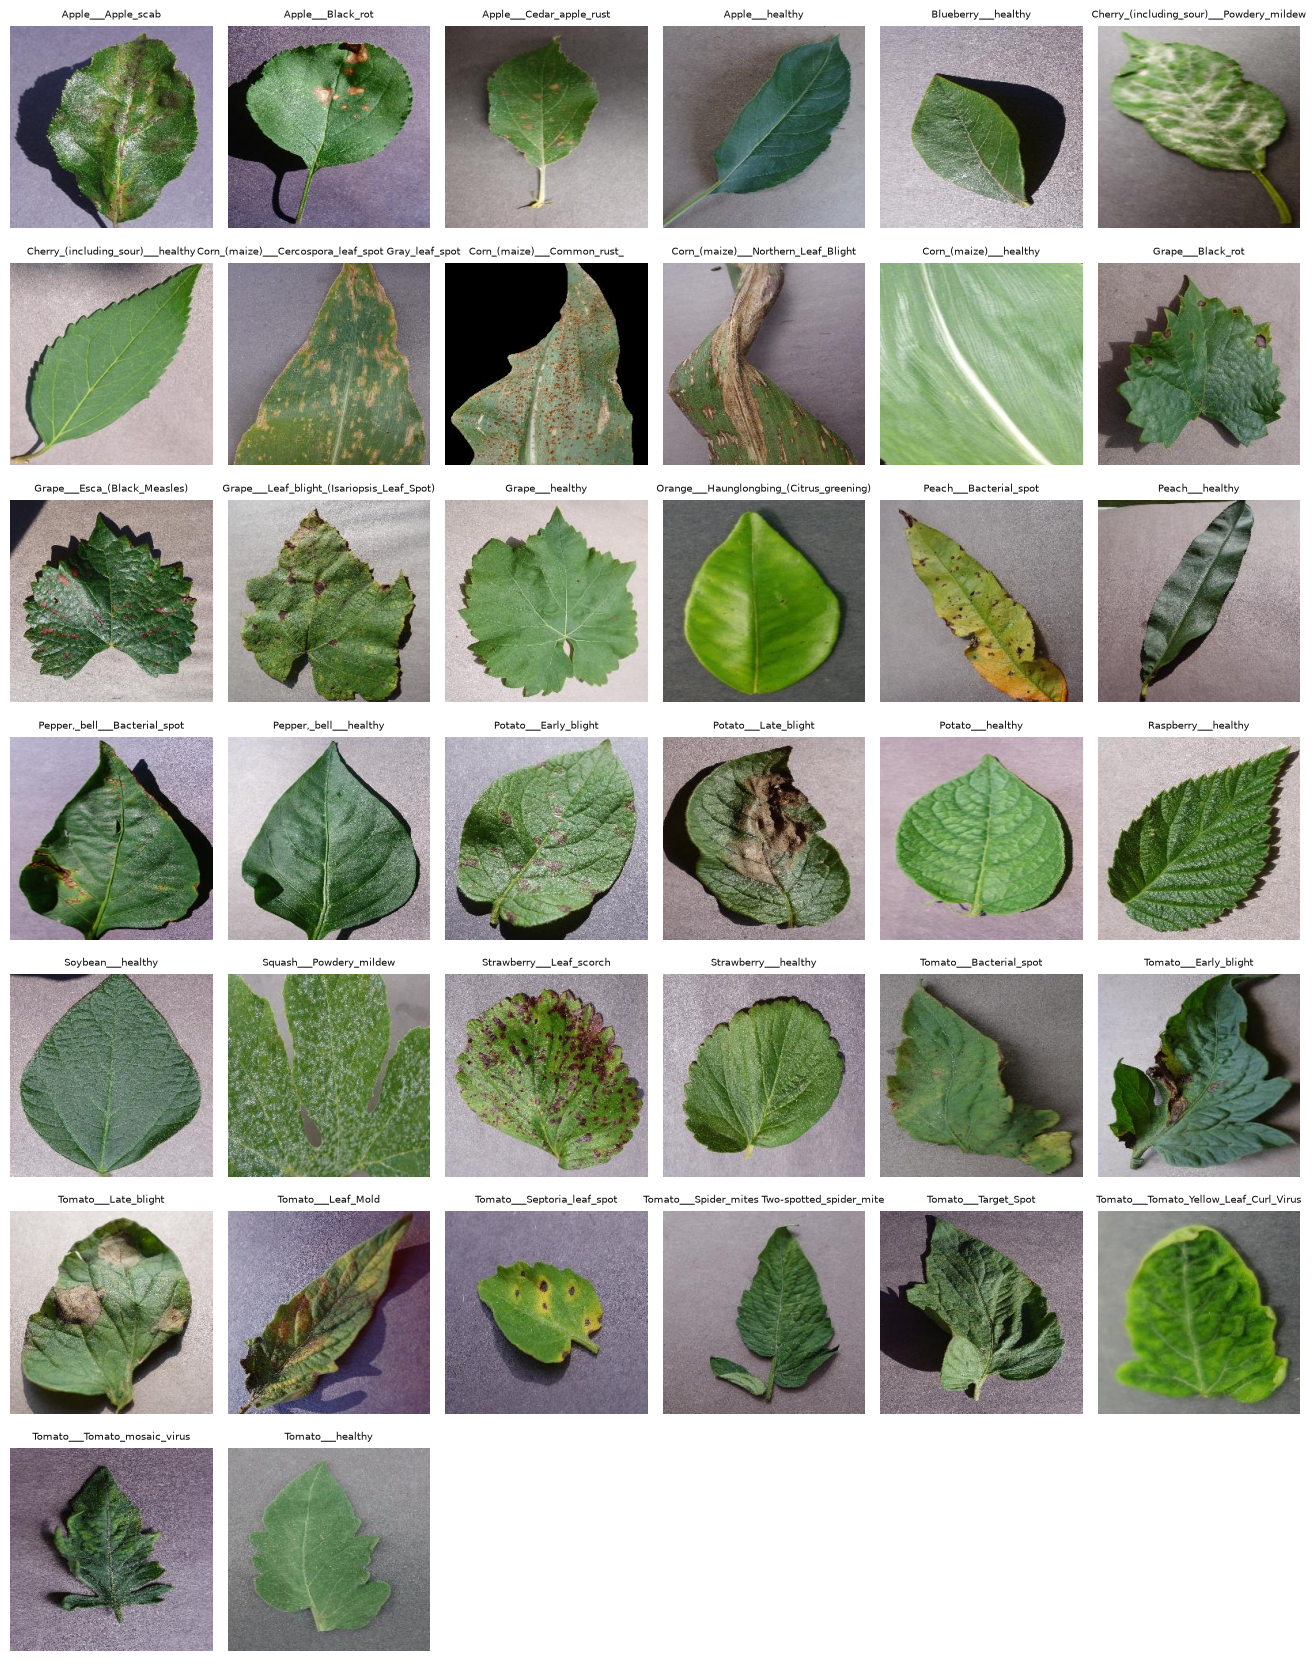

In [5]:
samples = eda.sample_image_paths(DATA_PATH, n_per_class=1)
classes = sorted(samples.keys())

cols = 6
rows = -(-len(classes) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.4))
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    img = Image.open(samples[cls][0])
    ax.imshow(img)
    ax.set_title(cls, fontsize=7, color=COLOR_TEXT)
    ax.axis("off")

for ax in axes[len(classes):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Image manifest -- size, mode, corruption check

Scans every image once (header-only reads) and caches the result, since a full
scan over ~54K images is slow to repeat on every run.

In [6]:
manifest_path = Path(cfg["logging"]["experiments_dir"]) / "eda" / "manifest.csv"
df = eda.build_manifest(DATA_PATH, cache_path=manifest_path)

print(df["readable"].value_counts())
corrupt = df[~df["readable"]]
print(f"Corrupt/unreadable files: {len(corrupt)}")
if len(corrupt):
    display(corrupt[["path", "class"]])

print("Unique widths:", sorted(df["width"].dropna().unique()))
print("Unique heights:", sorted(df["height"].dropna().unique()))
print("Unique modes:", df["mode"].dropna().unique())

readable
True    54305
Name: count, dtype: int64
Corrupt/unreadable files: 0
Unique widths: [np.int64(256)]
Unique heights: [np.int64(256)]
Unique modes: <StringArray>
['RGB', 'RGBA']
Length: 2, dtype: str


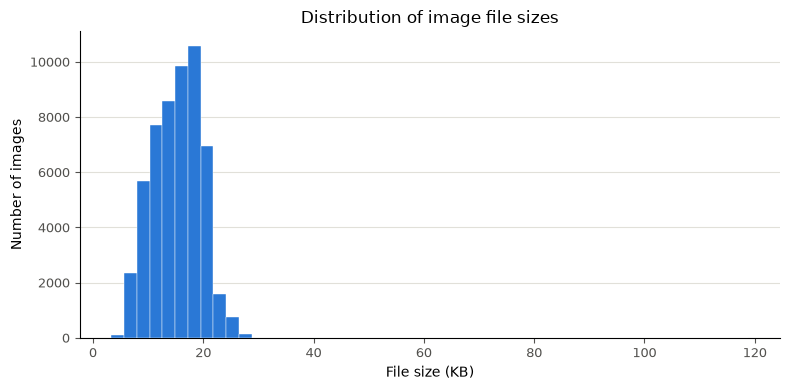

count    54305.000000
mean        15.299606
std          4.319369
min          3.359375
25%         11.994141
50%         15.582031
75%         18.602539
max        118.800781
Name: file_size_kb, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["file_size_kb"], bins=50, color=COLOR_PRIMARY, edgecolor="white", linewidth=0.3, zorder=3)
ax.set_xlabel("File size (KB)")
ax.set_ylabel("Number of images")
ax.set_title("Distribution of image file sizes")
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.tick_params(colors=COLOR_TEXT_MUTED, labelsize=9)
plt.tight_layout()
plt.show()

df["file_size_kb"].describe()

## Summary & implications for later phases

In [8]:
print(f"Total images: {counts.sum()} across {len(counts)} classes")
print(f"Class imbalance ratio (max/min): {counts.max() / counts.min():.2f}x")
print(f"Corrupt/unreadable files: {len(corrupt)}")
print(f"Image dimensions: {sorted(df['width'].dropna().unique())} x {sorted(df['height'].dropna().unique())}")
print(f"Color modes present: {list(df['mode'].dropna().unique())}")

Total images: 54305 across 38 classes
Class imbalance ratio (max/min): 36.23x
Corrupt/unreadable files: 0
Image dimensions: [np.int64(256)] x [np.int64(256)]
Color modes present: ['RGB', 'RGBA']


Takeaways to carry into Phase 2/3:

- **Class imbalance is severe: 36x** between the smallest class (`Potato___healthy`,
  152 images) and the largest (`Orange___Haunglongbing_(Citrus_greening)`, 5507
  images) -- not a minor nuisance. Phase 3's training harness should treat a
  weighted sampler and/or class-weighted loss as close to mandatory, and
  metrics must include macro-F1 / per-class recall, not just accuracy.
- **Images are a uniform 256x256, but not a uniform color mode**: one image
  (`Pepper,_bell___healthy`) is RGBA against 54,304 RGB images. Phase 2's
  `Dataset` must call `.convert("RGB")` on every image before transforms --
  otherwise that single file will crash the DataLoader with a channel-count
  mismatch the first time it's sampled into a batch. This is exactly the kind
  of one-in-54000 outlier a full manifest scan catches and a manual look would
  miss.
- **Zero unreadable/corrupt files** -- no need to filter or skip files, just
  the RGBA-normalization above.
- Images are lab-condition photos on plain backgrounds (see the sample grid
  above) -- worth remembering as a generalization caveat for the optional
  Phase 9 real-world robustness check.